# Необходимые функции и импорты библиотек

In [1]:
import os
os.chdir('E:/GitHubProjects/autolabeling_time_series_data/')

from typing import Literal, Callable
import numpy as np
import pandas as pd
pd.set_option('display.max_colwidth', 150)
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt


from src.clustering import Sklearn_kmeans_model, BIRCH_model, DBSCAN_model,AC_model
from src.clustering.Clustering_scorer import Clustering_scorer
from src.feature_extraction.manual_methods.TS_feature_extractor import Feature_extraction_method, Feature_extractor_pipeline
from src.feature_extraction.manual_methods.manual_feature_extraction import (
    no_fe,
    tsa_detrend, 
    statistical_features,
    paa_features,
    signal_peaks_features,
    stft_features,
    dft_components,
    dft_signal,
    dft_approximation,
    dwt_features,
    dwt_signal, 
    stl_trend,
    stl_seasonal,
    stl_noise,
    stl_features
)

from src.utils.parse_UCR import load_UCR
from src.feature_extraction.manual_methods.trend_fe_algo import *


from src.utils import plot_series, plot_series_grid
from scripts.synthetic_generators import *
from src.utils.transform_tools import split_train_test


In [2]:
def prepare_data(dataset_name, split_ratio=0.8):
    X, y, metadata = load_UCR(dataset_name)
    X_train, X_test, y_train, y_test = split_train_test(X, y, split_ratio, 42)
    # X_train = X_train.squeeze(1)
    # X_test = X_test.squeeze(1)
    
    print(X_train.shape, X_test.shape)
    print(np.unique(y_train))
    print(pd.Series(y_train).value_counts(normalize=True))
    print(pd.Series(y_test).value_counts(normalize=True))
    
    return X_train, X_test, y_train, y_test


In [3]:
# функции по изменению файла конфигурации для исключения ошибок и ускорения тестирования на синтетике

def adapt_kmeans(config, dist_params):
    param_grid = config['param_grid']

    if 'n_clusters' in param_grid:
        base = param_grid['n_clusters']
        n_clusters_base = dist_params.get('n_cluster', 2)
        low = max(base.get('low', 2), n_clusters_base - 2)
        high = n_clusters_base + 2

        param_grid['n_clusters']['low'] = low
        param_grid['n_clusters']['high'] = high

    return config


def adapt_dbscan(config, dist_params):
    param_grid = config['param_grid']

    if 'min_samples' in param_grid:
        base = param_grid['min_samples']
        sample_size = dist_params.get('sample_size', 100)
        new_low = max(base.get('low', 1), int(sample_size * 0.01))
        new_high = max(new_low + 5, int(sample_size * 0.1))

        param_grid['min_samples']['low'] = new_low
        param_grid['min_samples']['high'] = new_high

    if 'eps' in param_grid:
        base = param_grid['eps']
        ts_length = dist_params.get('ts_length', 100)
        noise_factor = 1.0 if ts_length < 500 else 1.5 if ts_length < 2000 else 2.0
        new_high = base.get('high', 20) * noise_factor

        param_grid['eps']['high'] = round(float(new_high), 2)
    
    return config


def adapt_birch(config, dist_params):
    param_grid = config['param_grid']

    if 'n_clusters' in param_grid:
        base = param_grid['n_clusters']
        low = base.get('low', 2)
        high = dist_params.get('n_cluster', 2) + 2

        param_grid['n_clusters']['low'] = low
        param_grid['n_clusters']['high'] = high

    if 'threshold' in param_grid:
        base = param_grid['threshold']
        value_scale = dist_params.get('value_scale', [0, 1])
        scale_range = value_scale[1] - value_scale[0]
        new_low = max(base.get('low', 0.1), scale_range * 0.01)
        new_high = max(new_low + 1, scale_range * 0.1)

        param_grid['threshold']['low'] = round(float(new_low), 2)
        param_grid['threshold']['high'] = round(float(new_high), 2)
    
    return config


def adapt_agglomerative(config, dist_params):
    return adapt_kmeans(config, dist_params)


def get_model(model_name:Literal['dbscan', 'birch', 'sklearn_kmeans', 'agglomerative'], X, y, dist_params:dict=None, model_config_path:str='configs/parameters_search/'):
    
    config = load_config_file(f'{model_config_path}/{model_name}.yaml')
    
    if model_name == 'dbscan':
        model = DBSCAN_model()
        if dist_params is not None:
            config = adapt_dbscan(config, dist_params)
        
    if model_name == 'birch':
        model = BIRCH_model()
        if dist_params is not None:
            config = adapt_birch(config, dist_params)
            
    if model_name == 'sklearn_kmeans':
        model = Sklearn_kmeans_model()
        if dist_params is not None:
            config = adapt_kmeans(config, dist_params)
        
    if model_name == 'agglomerative':
        model = AC_model()
        if dist_params is not None:
            config = adapt_agglomerative(config, dist_params)

    scorer = Clustering_scorer(
        metrics=None,
        debug=True 
        )

    result_df = scorer.grid_search(model=model, X=X, y_true=y, model_name=model_name, param_grid=config)

    return result_df

def get_result(X, y, segments_grid, fe_pipeline, dist_params, model_config_path):
    
    res_df = pd.DataFrame()
    
    for n_segment in segments_grid:
        if n_segment == 1:
            use_segm = False
        features = fe_pipeline.batch_extract(X, use_segmentation=use_segm, n_segments=n_segment, verbose=False)

        for (X_train, fe_params) in features:
            y_train = np.asarray(y)
            fe_params = fe_params

            for model_name in ['dbscan', 'birch', 'sklearn_kmeans', 'agglomerative']:
                model_df = get_model(model_name, X_train, y_train, dist_params, model_config_path)
                model_df['model_name'] = model_name
                model_df['fe_method']= list(fe_params.keys())[0]
                model_df['fe_params']= '__'.join(['_'.join([str(k), str(v)]) for k,v in list(fe_params.values())[0].items()])
                model_df['segment'] = n_segment
                
                res_df = pd.concat([res_df, model_df])
    
    return res_df

In [4]:
def visualize_clusters(X, y, save_path):
    for val in np.unique(y):
        plot_series(X[y == val].tolist(), show_legend=False, plot_title=f'Cluster {val}', save_path=f"{save_path}/Cluster {val}.png")


def visualize_latent_space(train_latents, train_labels, model_save_path):
    """
    Визуализация латентного пространства с помощью t-SNE.
    Объединяет train и val для проецирования, но различает их на графике.
    """
    # Применяем t-SNE ко всем данным сразу
    tsne = TSNE(n_components=2, random_state=42, init='random', perplexity=30)
    latents_2d = tsne.fit_transform(train_latents)

    # Визуализация
    plt.figure(figsize=(12, 8))

    # Точки из train
    scatter_train = plt.scatter(latents_2d[:, 0], latents_2d[:, 1], 
                                c=train_labels, cmap='tab10', s=60, 
                                label='Train', edgecolor='k', alpha=0.7)

    # Легенда
    unique_labels = np.unique(train_labels)
    handles, _ = scatter_train.legend_elements(prop="colors", num=len(unique_labels))
    plt.legend(handles, unique_labels, title="Classes")

    plt.title("Latent Space Visualization (t-SNE)")
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.grid(True)
    plt.tight_layout()
    if model_save_path is not None:
        plt.savefig(model_save_path)
        plt.close()
    else:
        plt.show()
        
    return latents_2d

def visualize_clusters(X, y, save_path):
    for val in np.unique(y):
        plot_series(X[y == val].tolist(), show_legend=False, plot_title=f'Cluster {val}', save_path=f"{save_path}/Cluster {val}.png")

def visualize_clusters_mean(X, y, save_path):
    plot_series([np.mean(X[y == val].tolist(), axis=0) for val in np.unique(y)], labels=[f'Cluster {val+1}' for val in np.unique(y).tolist()], show_legend=True, save_path=f"{save_path}/Mean_Clusters.png" if save_path is not None else None)


# Все преобразования 

In [9]:
for dataset_name in ['EthanolLevel', 'Rock', 'Ham', 'ShapeletSim', 'Mallat', 'ItalyPowerDemand', 'ElectricDeviceDetection', 'Earthquakes', 'Car', 'FaultDetectionA', 'DodgerLoopDay', 'ECG200', 'ECG5000', 'DucksAndGeese']:

    basic_path = Path('data/UCR_benchmark/results')/dataset_name
    basic_path.mkdir(exist_ok=True, parents=True)

    X_train, X_test, y_train, y_test = prepare_data(dataset_name)

    visualize_clusters(X_train, y_train, basic_path )
    visualize_clusters_mean(X_train, y_train, basic_path )

    for method, prefix, config_path in zip([no_fe, extract_acf_statistics, tsa_detrend, stl_trend, paa_features , statistical_features , dft_approximation, dft_components , dft_signal , extract_acf_statistics , dwt_features , dwt_signal , signal_peaks_features , stl_seasonal ], ['no_fe/', 'extract_acf_statistics/', 'tsa_detrend/', 'stl_trend/', 'paa_features/' , 'statistical_features/' , 'dft_approximation/', 'dft_components/' , 'dft_signal/' , 'extract_acf_statistics/' , 'dwt_features/' , 'dwt_signal/' , 'signal_peaks_features/' , 'stl_seasonal/' ], ['configs/manual_fe/no_fe.yaml', 'configs/manual_fe/trend/acf_statistics.yaml', 'configs/manual_fe/trend/tsa_detrend.yaml', 'configs/manual_fe/trend/stl_decomposition.yaml', 'configs/manual_fe/trend/paa.yaml', 'configs/manual_fe/trend/statistical_features.yaml', 'configs/manual_fe/dft_approximation.yaml', 'configs/manual_fe/dft_components.yaml', 'configs/manual_fe/dft_signal.yaml', 'configs/manual_fe/trend/acf_statistics.yaml', 'configs/manual_fe/dwt_features.yaml', 'configs/manual_fe/dwt_signal.yaml', 'configs/manual_fe/signal_peaks.yaml', 'configs/manual_fe/stl_decomposition.yaml']):

        fe_extractor = Feature_extraction_method(method, load_config_file(config_path))

        pipeline = Feature_extractor_pipeline([fe_extractor])
        res_df = get_result(X_train, y_train, range(1,10), pipeline, None, 'configs/parameters_search/trend')
        Path(f"{basic_path}/{prefix}/").mkdir(parents=True, exist_ok=True)

        res_df.sort_values('value', ascending=False).to_excel(f"{basic_path}/{prefix}/{dataset_name}.xlsx")


Old Classes: [1 2 3 4]
New Classes: [0 1 2 3]
(803, 1751) (201, 1751)
[0 1 2 3]
0    0.251557
2    0.250311
1    0.249066
3    0.249066
Name: proportion, dtype: float64
2    0.253731
3    0.248756
1    0.248756
0    0.248756
Name: proportion, dtype: float64
{'eps': [0.05, 1.2875, 2.525, 3.7625, 5.0], 'min_samples': [20, 70]}


Grid Search: 100%|██████████| 10/10 [00:00<00:00, 11.53it/s]


{'threshold': [0.05, 0.7875000000000001, 1.5250000000000001, 2.2625, 3.0], 'branching_factor': [10, 30], 'n_clusters': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]}


Grid Search: 100%|██████████| 190/190 [00:52<00:00,  3.61it/s]


{'n_clusters': [4, 5, 6, 7, 8, 9, 10, 11, 12], 'init': ['k-means++', 'random'], 'n_init': [10, 20], 'max_iter': [100, 250]}


...

{'threshold': [0.05, 0.7875000000000001, 1.5250000000000001, 2.2625, 3.0], 'branching_factor': [10, 30], 'n_clusters': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]}


Grid Search: 100%|██████████| 190/190 [00:48<00:00,  3.92it/s]


{'n_clusters': [4, 5, 6, 7, 8, 9, 10, 11, 12], 'init': ['k-means++', 'random'], 'n_init': [10, 20], 'max_iter': [100, 250]}


Grid Search:  89%|████████▉ | 64/72 [01:11<00:08,  1.11s/it]


KeyboardInterrupt: 

In [31]:
for dataset_name in [
    # TRAFFIC
    'Chinatown', 'MelbournePedestrian',
    # SPECTRO
    'EthanolConcentration', 'EthanolLevel', 'Rock', 'Ham', 
    # SIMULATED
    'ShapeletSim', 'Mallat', 
    # SENSOR
    'ItalyPowerDemand', 'ElectricDeviceDetection', 'Earthquakes', 'Car', 'FaultDetectionA', 'DodgerLoopDay', 'BasicMotions',
    # OTHER
    'ECG200', 'ECG5000', 'DucksAndGeese']:

    print(dataset_name)
    basic_path = Path('data/UCR_benchmark/results')/dataset_name
    basic_path.mkdir(exist_ok=True, parents=True)

    X_train, X_test, y_train, y_test = prepare_data(dataset_name)

    if len(X_train.shape) <= 2 or X_train.shape[1] == 1:
        X_train = X_train.squeeze(1)
        visualize_clusters(X_train, y_train, basic_path )
        visualize_clusters_mean(X_train, y_train, basic_path)
    else:        
        for dim in range(X_train.shape[1]):
            visualize_clusters(X_train[:,dim,:], y_train, basic_path/str(dim))
            visualize_clusters_mean(X_train[:,dim,:], y_train, basic_path/str(dim)) 

Chinatown
Old Classes: [1 2]
New Classes: [0 1]
(290, 1, 24) (73, 1, 24)
[0 1]
1    0.713793
0    0.286207
Name: proportion, dtype: float64
1    0.712329
0    0.287671
Name: proportion, dtype: float64
MelbournePedestrian
Old Classes: [ 1  2  3  4  5  6  7  8  9 10]
New Classes: [0 1 2 3 4 5 6 7 8 9]
(2765, 1, 24) (692, 1, 24)
[0 1 2 3 4 5 6 7 8 9]
3    0.105244
4    0.104882
9    0.104882
6    0.104882
0    0.104882
5    0.103797
1    0.103074
2    0.098011
7    0.086799
8    0.083544
Name: proportion, dtype: float64
9    0.105491
0    0.105491
6    0.105491
4    0.105491
5    0.104046
3    0.104046
1    0.102601
2    0.098266
7    0.086705
8    0.082370
Name: proportion, dtype: float64
EthanolConcentration
Old Classes: ['e35' 'e38' 'e40' 'e45']
New Classes: [0 1 2 3]
(419, 3, 1751) (105, 3, 1751)
[0 1 2 3]
1    0.250597
0    0.250597
2    0.250597
3    0.248210
Name: proportion, dtype: float64
2    0.257143
1    0.247619
0    0.247619
3    0.247619
Name: proportion, dtype: float64
Eth

In [5]:
# for sample in shock:
#     print(sample.shape)
#     dims = sample.shape[1]
#     for dim in dims:
#         sample[:,dim,:]        
dataset_name = 'Chinatown'
X_train, X_test, y_train, y_test = prepare_data(dataset_name)

basic_path = Path('data/UCR_benchmark/results')/dataset_name
basic_path.mkdir(exist_ok=True, parents=True)

# # visualize_clusters(X_train, y_train, basic_path )
# # visualize_clusters_mean(X_train, y_train, basic_path)
# for dim in range(X_train.shape[1]):
#     visualize_clusters(X_train[:,dim,:], y_train, basic_path/str(dim))
#     visualize_clusters_mean(X_train[:,dim,:], y_train, basic_path/str(dim)) 

Old Classes: [1 2]
New Classes: [0 1]
(290, 1, 24) (73, 1, 24)
[0 1]
1    0.713793
0    0.286207
Name: proportion, dtype: float64
1    0.712329
0    0.287671
Name: proportion, dtype: float64


In [6]:
X_train, X_test, y_train, y_test = prepare_data(dataset_name)


Old Classes: [1 2]
New Classes: [0 1]
(290, 1, 24) (73, 1, 24)
[0 1]
1    0.713793
0    0.286207
Name: proportion, dtype: float64
1    0.712329
0    0.287671
Name: proportion, dtype: float64


# Анализ трендов 

In [56]:
dataset_name = 'Chinatown'

basic_path = Path('data/UCR_benchmark/results')/dataset_name
basic_path.mkdir(exist_ok=True, parents=True)

X_train, X_test, y_train, y_test = prepare_data(dataset_name)

Old Classes: [1 2]
New Classes: [0 1]
(290, 1, 24) (73, 1, 24)
[0 1]
1    0.713793
0    0.286207
Name: proportion, dtype: float64
1    0.712329
0    0.287671
Name: proportion, dtype: float64


In [39]:
X_train

array([[[ 468.,  303.,  136., ..., 1105.,  907.,  554.]],

       [[ 623.,  601.,  280., ..., 1063.,  659.,  478.]],

       [[ 105.,   66.,   55., ...,  532.,  312.,  160.]],

       ...,

       [[ 120.,   57.,   37., ...,  630.,  393.,  232.]],

       [[ 242.,  100.,   63., ..., 1335., 1172.,  888.]],

       [[ 511.,  364.,  211., ..., 1163., 1053.,  733.]]])

In [8]:
no_fe_extractor = Feature_extraction_method(no_fe, load_config_file('configs/manual_fe/no_fe.yaml'))

baseline_pipeline = Feature_extractor_pipeline([no_fe_extractor])
nofe_res = get_result(X_train, y_train, [1], baseline_pipeline, None, 'configs/parameters_search/trend')
nofe_res.sort_values('value', ascending=False).to_excel(f"{basic_path}/{dataset_name}_nofe.xlsx")
visualize_clusters(X_train, y_train, basic_path / 'no_fe')
visualize_clusters_mean(X_train, y_train, basic_path / 'no_fe')

{'eps': [0.05, 1.2875, 2.525, 3.7625, 5.0], 'min_samples': [20, 70]}


Grid Search:   0%|          | 0/10 [00:00<?, ?it/s]

Grid Search: 100%|██████████| 10/10 [00:00<00:00, 11.48it/s]


{'threshold': [0.05, 0.7875000000000001, 1.5250000000000001, 2.2625, 3.0], 'branching_factor': [10, 30], 'n_clusters': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]}


Grid Search: 100%|██████████| 190/190 [00:56<00:00,  3.35it/s]


{'n_clusters': [4, 5, 6, 7, 8, 9, 10, 11, 12], 'init': ['k-means++', 'random'], 'n_init': [10, 20], 'max_iter': [100, 250]}


Grid Search: 100%|██████████| 72/72 [01:13<00:00,  1.02s/it]


{'n_clusters': [6, 7, 8, 9, 10], 'linkage': ['complete', 'average'], 'metric': ['euclidean', 'cosine']}


Grid Search: 100%|██████████| 20/20 [00:07<00:00,  2.71it/s]


In [ ]:
methods = [
    Feature_extraction_method(extract_acf_statistics, load_config_file('configs/manual_fe/trend/acf_statistics.yaml'))
]

acf_pipeline = Feature_extractor_pipeline(methods)
acf_res = get_result(X_train, y_train, range(1,5), acf_pipeline, None, 'configs/parameters_search/trend')
Path(f'{basic_path}/acf/').mkdir(parents=True, exist_ok=True)

acf_res.sort_values('value', ascending=False).to_excel(f"{basic_path}/acf/acf_res_{dataset_name}.xlsx")



{'eps': [0.05, 1.2875, 2.525, 3.7625, 5.0], 'min_samples': [1, 3, 5, 7, 9]}


Grid Search: 100%|██████████| 25/25 [00:00<00:00, 68.20it/s]


{'threshold': [0.05, 0.7875000000000001, 1.5250000000000001, 2.2625, 3.0], 'branching_factor': [10, 30], 'n_clusters': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]}


Grid Search: 100%|██████████| 190/190 [00:03<00:00, 57.19it/s]


{'n_clusters': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20], 'init': ['k-means++', 'random'], 'n_init': [10, 20], 'max_iter': [100, 200, 300]}


...

Grid Search: 100%|██████████| 190/190 [00:03<00:00, 57.76it/s]


{'n_clusters': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20], 'init': ['k-means++', 'random'], 'n_init': [10, 20], 'max_iter': [100, 200, 300]}


Grid Search: 100%|██████████| 228/228 [00:17<00:00, 12.77it/s]


{'n_clusters': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20], 'linkage': ['complete', 'average', 'single'], 'metric': ['euclidean', 'cosine', 'l1', 'l2']}


Grid Search: 100%|██████████| 228/228 [00:03<00:00, 69.54it/s]


In [32]:
methods = [
    Feature_extraction_method(tsa_detrend, load_config_file('configs/manual_fe/trend/tsa_detrend.yaml'))
]

detrend_pipeline = Feature_extractor_pipeline(methods)
detrend_res = get_result(X_train, y_train, range(1,5), detrend_pipeline, None, 'configs/parameters_search/trend')
Path(f'{basic_path}/detrend/').mkdir(parents=True, exist_ok=True)
detrend_res.sort_values('value', ascending=False).to_excel(f"{basic_path}/detrend/detrend_res_{dataset_name}.xlsx")


{'eps': [0.05, 1.2875, 2.525, 3.7625, 5.0], 'min_samples': [1, 3, 5, 7, 9]}


Grid Search: 100%|██████████| 25/25 [00:00<00:00, 56.82it/s]


{'threshold': [0.05, 0.7875000000000001, 1.5250000000000001, 2.2625, 3.0], 'branching_factor': [10, 30], 'n_clusters': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]}


Grid Search: 100%|██████████| 190/190 [00:08<00:00, 21.47it/s]


{'n_clusters': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20], 'init': ['k-means++', 'random'], 'n_init': [10, 20], 'max_iter': [100, 200, 300]}


...

Grid Search: 100%|██████████| 190/190 [00:08<00:00, 21.94it/s]


{'n_clusters': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20], 'init': ['k-means++', 'random'], 'n_init': [10, 20], 'max_iter': [100, 200, 300]}


Grid Search: 100%|██████████| 228/228 [00:19<00:00, 11.42it/s]


{'n_clusters': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20], 'linkage': ['complete', 'average', 'single'], 'metric': ['euclidean', 'cosine', 'l1', 'l2']}


Grid Search: 100%|██████████| 228/228 [00:03<00:00, 68.72it/s]


In [23]:
de_detrend = Feature_extraction_method(tsa_detrend, load_config_file('configs/manual_fe/trend/tsa_detrend.yaml'))

new_X_train = np.array([de_detrend.infer_segmented(row[0], 1, {'order':2}) for row in X_train])

Path(f'{basic_path}/detrend/').mkdir(parents=True, exist_ok=True)

# plot_series([row for row in new_X_train[y_train==0]], show_legend=False)
# plot_series([row for row in new_X_train[y_train==1]], show_legend=False)
visualize_clusters_mean(new_X_train, y_train, f'{basic_path}/detrend_vis/')
visualize_clusters(new_X_train, y_train, f"{basic_path}/detrend_vis/")
# new_X_train

In [73]:
df = pd.read_excel('E:/GitHubProjects/autolabeling_time_series_data/data/UCR_benchmark/results/Chinatown/detrend/detrend_res_Chinatown.xlsx').reset_index(drop=True)

In [93]:
np.unique(df.metric)#.loc[df.metric == 'f1', ['metric', 'value']][:100].plot()

array(['accuracy', 'ari', 'calinski_harabasz_score',
       'davies_bouldin_score', 'f1', 'nmi', 'precision', 'recall',
       'silhouette'], dtype=object)

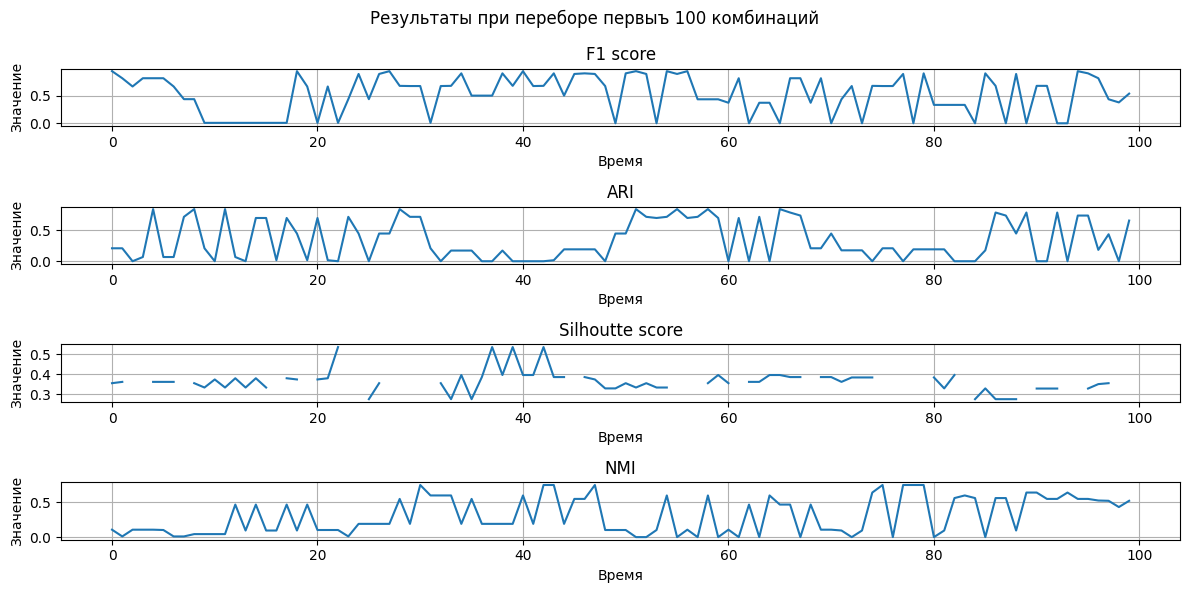

In [95]:
plot_series_grid([df.sort_values('Unnamed: 0').loc[df.metric == 'f1', 'value'][:100].reset_index(drop=True).values, df.sort_values('Unnamed: 0').loc[df.metric == 'ari', 'value'][:100].reset_index(drop=True).values, df.sort_values('Unnamed: 0').loc[df.metric == 'silhouette', 'value'][:100].reset_index(drop=True).values, df.sort_values('Unnamed: 0').loc[df.metric == 'nmi', 'value'][:100].reset_index(drop=True).values], ['F1 score', 'ARI', 'Silhoutte score', 'NMI'], plot_title='Результаты при переборе первыъ 100 комбинаций')

In [53]:
# [tsa_detrend(row, 1) for row in X_train[:5]]
tsa_detrend(X_train[0], 1), X_train[0]

(array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0.]]),
 array([[ 468.,  303.,  136.,  122.,   84.,   33.,   34.,   48.,  112.,
          263.,  263.,  292., 1112., 1501., 1373., 1589., 1451., 1514.,
         1634., 1694., 1452., 1105.,  907.,  554.]]))

In [33]:
methods = [
    Feature_extraction_method(stl_trend, load_config_file('configs/manual_fe/trend/stl_decomposition.yaml'))
]

stl_trend_pipeline = Feature_extractor_pipeline(methods)
stl_trend_res = get_result(X_train, y_train, range(1,5), stl_trend_pipeline, None,'configs/parameters_search/trend')
Path(f'{basic_path}/stl_trend/').mkdir(parents=True, exist_ok=True)
stl_trend_res.sort_values('value', ascending=False).to_excel(f"{basic_path}/stl_trend/stl_trend_{dataset_name}.xlsx")


{'eps': [0.05, 1.2875, 2.525, 3.7625, 5.0], 'min_samples': [1, 3, 5, 7, 9]}


Grid Search: 100%|██████████| 25/25 [00:00<00:00, 53.18it/s]


{'threshold': [0.05, 0.7875000000000001, 1.5250000000000001, 2.2625, 3.0], 'branching_factor': [10, 30], 'n_clusters': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]}


Grid Search: 100%|██████████| 190/190 [00:08<00:00, 22.29it/s]


{'n_clusters': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20], 'init': ['k-means++', 'random'], 'n_init': [10, 20], 'max_iter': [100, 200, 300]}


...

Grid Search: 100%|██████████| 190/190 [00:08<00:00, 23.36it/s]


{'n_clusters': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20], 'init': ['k-means++', 'random'], 'n_init': [10, 20], 'max_iter': [100, 200, 300]}


Grid Search: 100%|██████████| 228/228 [00:19<00:00, 11.56it/s]


{'n_clusters': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20], 'linkage': ['complete', 'average', 'single'], 'metric': ['euclidean', 'cosine', 'l1', 'l2']}


Grid Search: 100%|██████████| 228/228 [00:03<00:00, 70.29it/s]


In [34]:
methods = [
    Feature_extraction_method(paa_features, load_config_file('configs/manual_fe/trend/paa.yaml'))
]

paa_pipeline = Feature_extractor_pipeline(methods)
paa_res = get_result(X_train, y_train, range(1,5), paa_pipeline, None, 'configs/parameters_search/trend')
Path(f'{basic_path}/paa/').mkdir(parents=True, exist_ok=True)
paa_res.sort_values('value', ascending=False).to_excel(f"{basic_path}/paa/paa_{dataset_name}.xlsx")

e:\GitHubProjects\autolabeling_time_series_data\.basic_312\Lib\site-packages\tslearn\utils\utils.py:90: UserWarning: 2-Dimensional data passed. Assuming these are 1 1-dimensional timeseries
  warnings.warn(
e:\GitHubProjects\autolabeling_time_series_data\.basic_312\Lib\site-packages\tslearn\utils\utils.py:90: UserWarning: 2-Dimensional data passed. Assuming these are 1 1-dimensional timeseries
  warnings.warn(
e:\GitHubProjects\autolabeling_time_series_data\.basic_312\Lib\site-packages\tslearn\utils\utils.py:90: UserWarning: 2-Dimensional data passed. Assuming these are 1 1-dimensional timeseries
  warnings.warn(
e:\GitHubProjects\autolabeling_time_series_data\.basic_312\Lib\site-packages\tslearn\utils\utils.py:90: UserWarning: 2-Dimensional data passed. Assuming these are 1 1-dimensional timeseries
  warnings.warn(
e:\GitHubProjects\autolabeling_time_series_data\.basic_312\Lib\site-packages\tslearn\utils\utils.py:90: UserWarning: 2-Dimensional data passed. Assuming these are 1 1-dimen

{'eps': [0.05, 1.2875, 2.525, 3.7625, 5.0], 'min_samples': [1, 3, 5, 7, 9]}


Grid Search: 100%|██████████| 25/25 [00:00<00:00, 83.31it/s]


{'threshold': [0.05, 0.7875000000000001, 1.5250000000000001, 2.2625, 3.0], 'branching_factor': [10, 30], 'n_clusters': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]}


Grid Search: 100%|██████████| 190/190 [00:07<00:00, 26.55it/s]


...

{'n_clusters': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20], 'init': ['k-means++', 'random'], 'n_init': [10, 20], 'max_iter': [100, 200, 300]}


Grid Search: 100%|██████████| 228/228 [00:19<00:00, 11.58it/s]


{'n_clusters': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20], 'linkage': ['complete', 'average', 'single'], 'metric': ['euclidean', 'cosine', 'l1', 'l2']}


Grid Search:  99%|█████████▊| 225/228 [00:03<00:00, 64.93it/s]


KeyboardInterrupt: 

In [ ]:
methods = [
    Feature_extraction_method(statistical_features, load_config_file('configs/manual_fe/trend/statistical_features.yaml'))
]

stats_pipeline = Feature_extractor_pipeline(methods)
stats_res = get_result(X_train, y_train, range(1,5), stats_pipeline, None,'configs/parameters_search/trend')
Path(f'{basic_path}/stats/').mkdir(parents=True, exist_ok=True)

stats_res.sort_values('value', ascending=False).to_excel(f"{basic_path}/stats/stats_{dataset_name}.xlsx")


{'eps': [0.05, 1.2875, 2.525, 3.7625, 5.0], 'min_samples': [1, 3, 5]}


Grid Search: 100%|██████████| 15/15 [00:00<00:00, 107.05it/s]


{'threshold': [0.05, 0.3, 0.55, 0.8, 1.05], 'branching_factor': [10, 30], 'n_clusters': [2, 3, 4, 5, 6, 7]}


Grid Search: 100%|██████████| 60/60 [00:00<00:00, 101.99it/s]


{'n_clusters': [3, 4, 5, 6, 7], 'init': ['k-means++', 'random'], 'n_init': [10, 20], 'max_iter': [100, 200, 300]}


...

Grid Search: 100%|██████████| 60/60 [00:00<00:00, 83.08it/s]


{'n_clusters': [3, 4, 5, 6, 7], 'init': ['k-means++', 'random'], 'n_init': [10, 20], 'max_iter': [100, 200, 300]}


Grid Search: 100%|██████████| 60/60 [00:02<00:00, 25.02it/s]


{'n_clusters': [3, 4, 5, 6, 7], 'linkage': ['complete', 'average', 'single'], 'metric': ['euclidean', 'cosine', 'l1', 'l2']}


Grid Search: 100%|██████████| 60/60 [00:00<00:00, 95.25it/s]


In [ ]:
def get_top3(df, metric_name='ari'):

    return [df.loc[(df.model_name == name)&(df.metric == metric_name), ['value']].sort_values('value', ascending=False)[:3].mean().round(2).item() for name in ['dbscan', 'birch', 'sklearn_kmeans', 'agglomerative']]

def clustering_table(name, metric_name):
    return pd.DataFrame([get_top3(nofe_res, metric_name), get_top3(detrend_res, metric_name), get_top3(stl_trend_res, metric_name), get_top3(paa_res, metric_name), get_top3(stats_res, metric_name)], columns=['dbscan', 'birch', 'kmeans', 'agglomerative'], index = ['no', 'detrend', 'stl', 'paa', 'statistics']).to_excel(f'{basic_path}/{metric_name}_clustering_{name}.xlsx')

def get_top5(df):
    return [df.loc[(df.metric == metric_name), ['value']].sort_values('value', ascending=False)[:5].mean().round(2).item() for metric_name in ['ari', 'nmi', 'silhouette', 'f1']]

def evaluation_table(name):
    return pd.DataFrame([get_top5(nofe_res), get_top5(detrend_res), get_top5(stl_trend_res), get_top5(paa_res), get_top5(stats_res)], columns=['ari', 'nmi', 'silhouette', 'f1'], index =['no', 'detrend', 'stl', 'paa', 'statistics']).to_excel(f'{basic_path}/clustering_performance_{name}.xlsx')

def get_top5_segm(df, n_segm:int=1):
    return [df.loc[(df.metric == metric_name)&(df.segment ==n_segm), ['value']].sort_values('value', ascending=False)[:5].mean().round(2).item() for metric_name in ['ari', 'nmi', 'silhouette', 'f1']]

def evaluation_table_segm(name, segm):
    return pd.DataFrame([get_top5(nofe_res), get_top5_segm(detrend_res, segm), get_top5_segm(stl_trend_res, segm), get_top5_segm(paa_res, segm), get_top5_segm(stats_res, segm)], columns=['ari', 'nmi', 'silhouette', 'f1'], index =['no', 'detrend', 'stl', 'paa', 'statistics']).to_excel(f'{basic_path}/{segm}_clustering_performance_{name}.xlsx')


for metric in ['ari', 'silhouette', 'f1']:
    clustering_table(dataset_name, metric)
evaluation_table(dataset_name)
for i in stats_res.segment.unique():
    evaluation_table_segm(dataset_name, i)

In [ ]:
methods = [
    Feature_extraction_method(dft_approximation, load_config_file('configs/manual_fe/dft_approximation.yaml'))
]

dft_apr_pipeline = Feature_extractor_pipeline(methods)
dft_apr_res = get_result(sample_seasonal, labels_seasonal, range(1,2), dft_apr_pipeline, None, 'configs/parameters_search/')
dft_apr_res.sort_values('value', ascending=False).to_excel(f"{basic_path}/dft_apr_res_{dataset_name}.xlsx")

{'eps': [0.05, 1.7875, 3.525, 5.2625, 7.0], 'min_samples': [1, 6]}


Grid Search: 100%|██████████| 10/10 [00:00<00:00, 68.01it/s]


{'threshold': [0.05, 0.3, 0.55, 0.8, 1.05], 'branching_factor': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100], 'n_clusters': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]}


Grid Search: 100%|██████████| 550/550 [00:06<00:00, 86.29it/s]


{'n_clusters': [8, 9, 10, 11, 12], 'init': ['k-means++', 'random'], 'n_init': [5, 15], 'max_iter': [100, 200, 300]}


...

Grid Search: 100%|██████████| 550/550 [00:06<00:00, 87.54it/s]


{'n_clusters': [8, 9, 10, 11, 12], 'init': ['k-means++', 'random'], 'n_init': [5, 15], 'max_iter': [100, 200, 300]}


Grid Search: 100%|██████████| 60/60 [00:01<00:00, 33.40it/s]


{'n_clusters': [8, 9, 10, 11, 12], 'linkage': ['complete', 'average', 'single'], 'metric': ['euclidean', 'cosine', 'l1', 'l2']}


Grid Search: 100%|██████████| 60/60 [00:00<00:00, 116.04it/s]


In [ ]:
methods = [
    Feature_extraction_method(dft_components, load_config_file('configs/manual_fe/dft_components.yaml'))
]

dft_comp_pipeline = Feature_extractor_pipeline(methods)
dft_comp_res = get_result(sample_seasonal, labels_seasonal, range(1,2), dft_comp_pipeline, None, 'configs/parameters_search/')
dft_comp_res.sort_values('value', ascending=False).to_excel(f"{basic_path}/dft_comp_res_{dataset_name}.xlsx")

{'eps': [0.05, 1.7875, 3.525, 5.2625, 7.0], 'min_samples': [1, 6]}


Grid Search: 100%|██████████| 10/10 [00:00<00:00, 139.03it/s]


{'threshold': [0.05, 0.3, 0.55, 0.8, 1.05], 'branching_factor': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100], 'n_clusters': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]}


Grid Search: 100%|██████████| 550/550 [00:05<00:00, 95.36it/s]


{'n_clusters': [8, 9, 10, 11, 12], 'init': ['k-means++', 'random'], 'n_init': [5, 15], 'max_iter': [100, 200, 300]}


...

Grid Search: 100%|██████████| 550/550 [00:06<00:00, 85.45it/s]


{'n_clusters': [8, 9, 10, 11, 12], 'init': ['k-means++', 'random'], 'n_init': [5, 15], 'max_iter': [100, 200, 300]}


Grid Search: 100%|██████████| 60/60 [00:01<00:00, 34.07it/s]


{'n_clusters': [8, 9, 10, 11, 12], 'linkage': ['complete', 'average', 'single'], 'metric': ['euclidean', 'cosine', 'l1', 'l2']}


Grid Search: 100%|██████████| 60/60 [00:00<00:00, 112.11it/s]


In [ ]:
methods = [
    Feature_extraction_method(dft_signal, load_config_file('configs/manual_fe/dft_signal.yaml'))
]

dft_sig_pipeline = Feature_extractor_pipeline(methods)
dft_sig_res = get_result(sample_seasonal, labels_seasonal, range(1,2), dft_sig_pipeline, None, 'configs/parameters_search/')
dft_sig_res.sort_values('value', ascending=False).to_excel(f"{basic_path}/dft_sig_res_{dataset_name}.xlsx")

{'eps': [0.05, 1.7875, 3.525, 5.2625, 7.0], 'min_samples': [1, 6]}


Grid Search: 100%|██████████| 10/10 [00:00<00:00, 62.88it/s]


{'threshold': [0.05, 0.3, 0.55, 0.8, 1.05], 'branching_factor': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100], 'n_clusters': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]}


Grid Search: 100%|██████████| 550/550 [00:06<00:00, 90.19it/s]


{'n_clusters': [8, 9, 10, 11, 12], 'init': ['k-means++', 'random'], 'n_init': [5, 15], 'max_iter': [100, 200, 300]}


...

Grid Search: 100%|██████████| 550/550 [00:06<00:00, 91.22it/s]


{'n_clusters': [8, 9, 10, 11, 12], 'init': ['k-means++', 'random'], 'n_init': [5, 15], 'max_iter': [100, 200, 300]}


Grid Search: 100%|██████████| 60/60 [00:01<00:00, 34.53it/s]


{'n_clusters': [8, 9, 10, 11, 12], 'linkage': ['complete', 'average', 'single'], 'metric': ['euclidean', 'cosine', 'l1', 'l2']}


Grid Search: 100%|██████████| 60/60 [00:00<00:00, 114.25it/s]


In [ ]:
methods = [
    Feature_extraction_method(extract_acf_statistics, load_config_file('configs/manual_fe/trend/acf_statistics.yaml'))
]

acf_pipeline = Feature_extractor_pipeline(methods)
acf_res = get_result(sample_seasonal, labels_seasonal, range(1,2), acf_pipeline, None, 'configs/parameters_search/trend')
acf_res.sort_values('value', ascending=False).to_excel(f"{basic_path}/acf_res_{dataset_name}.xlsx")

# acf_res.loc[acf_res.metric=='f1'].sort_values('value', ascending=False).head(15)

{'eps': [0.05, 1.2875, 2.525, 3.7625, 5.0], 'min_samples': [1, 3, 5]}


Grid Search: 100%|██████████| 15/15 [00:00<00:00, 148.97it/s]


{'threshold': [0.05, 0.3, 0.55, 0.8, 1.05], 'branching_factor': [10, 30], 'n_clusters': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]}


Grid Search: 100%|██████████| 110/110 [00:00<00:00, 127.80it/s]


{'n_clusters': [8, 9, 10, 11, 12], 'init': ['k-means++', 'random'], 'n_init': [10, 20], 'max_iter': [100, 200, 300]}


...

Grid Search: 100%|██████████| 110/110 [00:01<00:00, 90.81it/s]


{'n_clusters': [8, 9, 10, 11, 12], 'init': ['k-means++', 'random'], 'n_init': [10, 20], 'max_iter': [100, 200, 300]}


Grid Search: 100%|██████████| 60/60 [00:02<00:00, 25.49it/s]


{'n_clusters': [8, 9, 10, 11, 12], 'linkage': ['complete', 'average', 'single'], 'metric': ['euclidean', 'cosine', 'l1', 'l2']}


Grid Search: 100%|██████████| 60/60 [00:00<00:00, 103.95it/s]


In [ ]:
methods = [
    Feature_extraction_method(dwt_features, load_config_file('configs/manual_fe/dwt_features.yaml'))
]

dwt_feat_pipeline = Feature_extractor_pipeline(methods)
dwt_feat_res = get_result(sample_seasonal, labels_seasonal, range(1,2), dwt_feat_pipeline, None, 'configs/parameters_search')
dwt_feat_res.sort_values('value', ascending=False).to_excel(f"{basic_path}/dwt_feat_res_{dataset_name}.xlsx")

# acf_res.loc[acf_res.metric=='f1'].sort_values('value', ascending=False).head(15)

{'eps': [0.05, 1.7875, 3.525, 5.2625, 7.0], 'min_samples': [1, 6]}


Grid Search: 100%|██████████| 10/10 [00:00<00:00, 152.07it/s]


{'threshold': [0.05, 0.3, 0.55, 0.8, 1.05], 'branching_factor': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100], 'n_clusters': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]}


Grid Search: 100%|██████████| 550/550 [00:04<00:00, 134.98it/s]


{'n_clusters': [8, 9, 10, 11, 12], 'init': ['k-means++', 'random'], 'n_init': [5, 15], 'max_iter': [100, 200, 300]}


...

Grid Search: 100%|██████████| 550/550 [00:05<00:00, 106.36it/s]


{'n_clusters': [8, 9, 10, 11, 12], 'init': ['k-means++', 'random'], 'n_init': [5, 15], 'max_iter': [100, 200, 300]}


Grid Search: 100%|██████████| 60/60 [00:01<00:00, 34.95it/s]


{'n_clusters': [8, 9, 10, 11, 12], 'linkage': ['complete', 'average', 'single'], 'metric': ['euclidean', 'cosine', 'l1', 'l2']}


Grid Search: 100%|██████████| 60/60 [00:00<00:00, 114.63it/s]


In [ ]:
methods = [
    Feature_extraction_method(dwt_signal, load_config_file('configs/manual_fe/dwt_signal.yaml'))
]

dwt_sig_pipeline = Feature_extractor_pipeline(methods)
dwt_sig_res = get_result(sample_seasonal, labels_seasonal, range(1,2), dwt_sig_pipeline, None, 'configs/parameters_search')
dwt_sig_res.sort_values('value', ascending=False).to_excel(f"{basic_path}/dwt_sig_res_{dataset_name}.xlsx")

# acf_res.loc[acf_res.metric=='f1'].sort_values('value', ascending=False).head(15)

{'eps': [0.05, 1.7875, 3.525, 5.2625, 7.0], 'min_samples': [1, 6]}


Grid Search: 100%|██████████| 10/10 [00:00<00:00, 64.90it/s]


{'threshold': [0.05, 0.3, 0.55, 0.8, 1.05], 'branching_factor': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100], 'n_clusters': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]}


Grid Search: 100%|██████████| 550/550 [00:06<00:00, 86.95it/s]


{'n_clusters': [8, 9, 10, 11, 12], 'init': ['k-means++', 'random'], 'n_init': [5, 15], 'max_iter': [100, 200, 300]}


...

Grid Search: 100%|██████████| 550/550 [00:06<00:00, 85.52it/s]


{'n_clusters': [8, 9, 10, 11, 12], 'init': ['k-means++', 'random'], 'n_init': [5, 15], 'max_iter': [100, 200, 300]}


Grid Search: 100%|██████████| 60/60 [00:01<00:00, 33.34it/s]


{'n_clusters': [8, 9, 10, 11, 12], 'linkage': ['complete', 'average', 'single'], 'metric': ['euclidean', 'cosine', 'l1', 'l2']}


Grid Search: 100%|██████████| 60/60 [00:00<00:00, 112.35it/s]


In [ ]:
methods = [
    Feature_extraction_method(signal_peaks_features, load_config_file('configs/manual_fe/signal_peaks.yaml'))
]

sig_peaks_pipeline = Feature_extractor_pipeline(methods)
sig_peaks_res = get_result(sample_seasonal, labels_seasonal, range(1,2), sig_peaks_pipeline, None, 'configs/parameters_search')
sig_peaks_res.sort_values('value', ascending=False).to_excel(f"{basic_path}/sig_peaks_res_{dataset_name}.xlsx")


{'eps': [0.05, 1.7875, 3.525, 5.2625, 7.0], 'min_samples': [1, 6]}


Grid Search: 100%|██████████| 10/10 [00:00<00:00, 85.46it/s]


{'threshold': [0.05, 0.3, 0.55, 0.8, 1.05], 'branching_factor': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100], 'n_clusters': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]}


Grid Search: 100%|██████████| 550/550 [00:06<00:00, 82.99it/s]


{'n_clusters': [8, 9, 10, 11, 12], 'init': ['k-means++', 'random'], 'n_init': [5, 15], 'max_iter': [100, 200, 300]}


Grid Search: 100%|██████████| 60/60 [00:01<00:00, 31.10it/s]


{'n_clusters': [8, 9, 10, 11, 12], 'linkage': ['complete', 'average', 'single'], 'metric': ['euclidean', 'cosine', 'l1', 'l2']}


Grid Search: 100%|██████████| 60/60 [00:00<00:00, 106.62it/s]


In [ ]:
methods = [
    Feature_extraction_method(stl_seasonal, load_config_file('configs/manual_fe/stl_decomposition.yaml'))
]

stl_seas_pipeline = Feature_extractor_pipeline(methods)
stl_seas_res = get_result(sample_seasonal, labels_seasonal, range(1,5), stl_seas_pipeline, None, 'configs/parameters_search')
stl_seas_res.sort_values('value', ascending=False).to_excel(f"{basic_path}/stl_seas_res_{dataset_name}.xlsx")


{'eps': [0.05, 1.7875, 3.525, 5.2625, 7.0], 'min_samples': [1, 6]}


Grid Search: 100%|██████████| 10/10 [00:00<00:00, 48.14it/s]


{'threshold': [0.05, 0.3, 0.55, 0.8, 1.05], 'branching_factor': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100], 'n_clusters': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]}


Grid Search: 100%|██████████| 550/550 [00:04<00:00, 124.30it/s]


{'n_clusters': [8, 9, 10, 11, 12], 'init': ['k-means++', 'random'], 'n_init': [5, 15], 'max_iter': [100, 200, 300]}


...

Grid Search: 100%|██████████| 550/550 [00:06<00:00, 87.16it/s]


{'n_clusters': [8, 9, 10, 11, 12], 'init': ['k-means++', 'random'], 'n_init': [5, 15], 'max_iter': [100, 200, 300]}


Grid Search: 100%|██████████| 60/60 [00:01<00:00, 33.24it/s]


{'n_clusters': [8, 9, 10, 11, 12], 'linkage': ['complete', 'average', 'single'], 'metric': ['euclidean', 'cosine', 'l1', 'l2']}


Grid Search: 100%|██████████| 60/60 [00:00<00:00, 109.58it/s]


In [ ]:
def get_top3(df, metric_name='ari'):

    return [df.loc[(df.model_name == name)&(df.metric == metric_name), ['value']].sort_values('value', ascending=False)[:3].mean().round(2).item() for name in ['dbscan', 'birch', 'sklearn_kmeans', 'agglomerative']]


def clustering_table(name, metric_name):
    return pd.DataFrame([get_top3(nofe_res, metric_name), get_top3(dft_apr_res, metric_name), get_top3(dft_comp_res, metric_name), get_top3(dft_sig_res, metric_name), get_top3(acf_res, metric_name), get_top3(dwt_feat_res, metric_name), get_top3(dwt_sig_res, metric_name), get_top3(sig_peaks_res, metric_name), get_top3(stl_seas_res, metric_name)], columns=['dbscan', 'birch', 'kmeans', 'agglomerative'], index = ['no', 'dft_approximation', 'dft_components', 'dft_signal', 'acf_features', 'dwt_features', 'dwt_signal', 'signal_peaks_features', 'stl_seasonal']).to_excel(f'{basic_path}/{metric_name}_clustering_{name}.xlsx')

def get_top5(df):
    return [df.loc[(df.metric == metric_name), ['value']].sort_values('value', ascending=False)[:5].mean().round(2).item() for metric_name in ['ari', 'nmi', 'silhouette', 'f1']]

def evaluation_table(name):
    return pd.DataFrame([get_top5(nofe_res), get_top5(dft_apr_res), get_top5(dft_comp_res), get_top5(dft_sig_res), get_top5(acf_res), get_top5(dwt_feat_res), get_top5(dwt_sig_res), get_top5(sig_peaks_res), get_top5(stl_seas_res)], columns=['ari', 'nmi', 'silhouette', 'f1'], index =['no', 'dft_approximation', 'dft_components', 'dft_signal', 'acf_features', 'dwt_features', 'dwt_signal', 'signal_peaks_features', 'stl_seasonal']).to_excel(f'{basic_path}/clustering_performance_{name}.xlsx')

def get_top5_segm(df, n_segm:int=1):
    return [df.loc[(df.metric == metric_name)&(df.segment ==n_segm), ['value']].sort_values('value', ascending=False)[:5].mean().round(2).item() for metric_name in ['ari', 'nmi', 'silhouette', 'f1']]

def evaluation_table_segm(name, segm):
    return pd.DataFrame([get_top5(nofe_res), get_top5_segm(dft_apr_res, segm), get_top5_segm(dft_comp_res, segm), get_top5_segm(dft_sig_res, segm), get_top5_segm(acf_res, segm), get_top5_segm(dwt_feat_res, segm), get_top5_segm(dwt_sig_res, segm), get_top5_segm(sig_peaks_res, segm), get_top5_segm(stl_seas_res, segm)], columns=['ari', 'nmi', 'silhouette', 'f1'], index =['no', 'dft_approximation', 'dft_components', 'dft_signal', 'acf_features', 'dwt_features', 'dwt_signal', 'signal_peaks_features', 'stl_seasonal']).to_excel(f'{basic_path}/{segm}_clustering_performance_{name}.xlsx')


for metric in ['ari', 'silhouette', 'f1']:
    clustering_table(dataset_name, metric)
evaluation_table(dataset_name)
for i in sig_peaks_res.segment.unique():
    evaluation_table_segm(dataset_name, i)